# Amino Acid Mutation Frequency Visualization Demo

This notebook demonstrates the new mutation frequency visualization features added to the antigentools package.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from antigentools.antigen_reader import AntigenReader
from antigentools.plot import plot_mutation_heatmap
from antigentools.utils import translate_dna_to_aa

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

/Users/zthornto/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Reference Sequence and Process FASTA File

First, we'll load the reference HA sequence and use the AntigenReader to process a FASTA file and calculate mutation frequencies.

In [2]:
# Initialize AntigenReader
reader = AntigenReader()

# Load reference HA sequence from file
ref_fasta = "../data/flu-simulated-150k-samples/ref_HA.fasta"
for record in SeqIO.parse(ref_fasta, "fasta"):
    ref_dna_seq = str(record.seq)
    break

# Translate reference DNA to amino acids
ref_aa_seq = translate_dna_to_aa(ref_dna_seq)
print(f"Reference sequence length: {len(ref_dna_seq)} nucleotides, {len(ref_aa_seq)} amino acids")
print(f"Reference AA sequence (first 50 aa): {ref_aa_seq[:50]}...")

# Path to your FASTA file with sequences to analyze
# Update this to point to your actual sequence file
fasta_file = "../data/flu-simulated-150k-samples/antigen-outputs/sequences.fasta"

# Process FASTA file to get mutation frequencies using the reference sequence
mutation_df = reader.fasta_to_aa_mutations(fasta_file, reference_seq=ref_aa_seq)

# Display summary
print(f"\nFound {len(mutation_df)} mutations across {mutation_df['n_sequences'].iloc[0]} sequences")
print(f"Reference type: {mutation_df['reference_type'].iloc[0]}")
mutation_df.head(10)

Reference sequence length: 1698 nucleotides, 566 amino acids
Reference AA sequence (first 50 aa): MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTITNDQI...

Found 1636 mutations across 5714 sequences
Reference type: provided


,position,reference_aa,variant_aa,count,frequency,n_sequences,reference_type
0,1,M,T,3,0.000525,5714,provided
1,1,M,V,3,0.000525,5714,provided
2,1,M,I,3,0.000525,5714,provided
3,1,M,K,1,0.000175,5714,provided
4,2,K,M,1,0.000175,5714,provided
5,2,K,E,1,0.000175,5714,provided
6,2,K,R,1,0.000175,5714,provided
7,2,K,T,1,0.000175,5714,provided
8,3,T,P,1,0.000175,5714,provided
9,3,T,I,3,0.000525,5714,provided


## 2. Basic Mutation Frequency Heatmap

Create a simple heatmap showing all mutations.

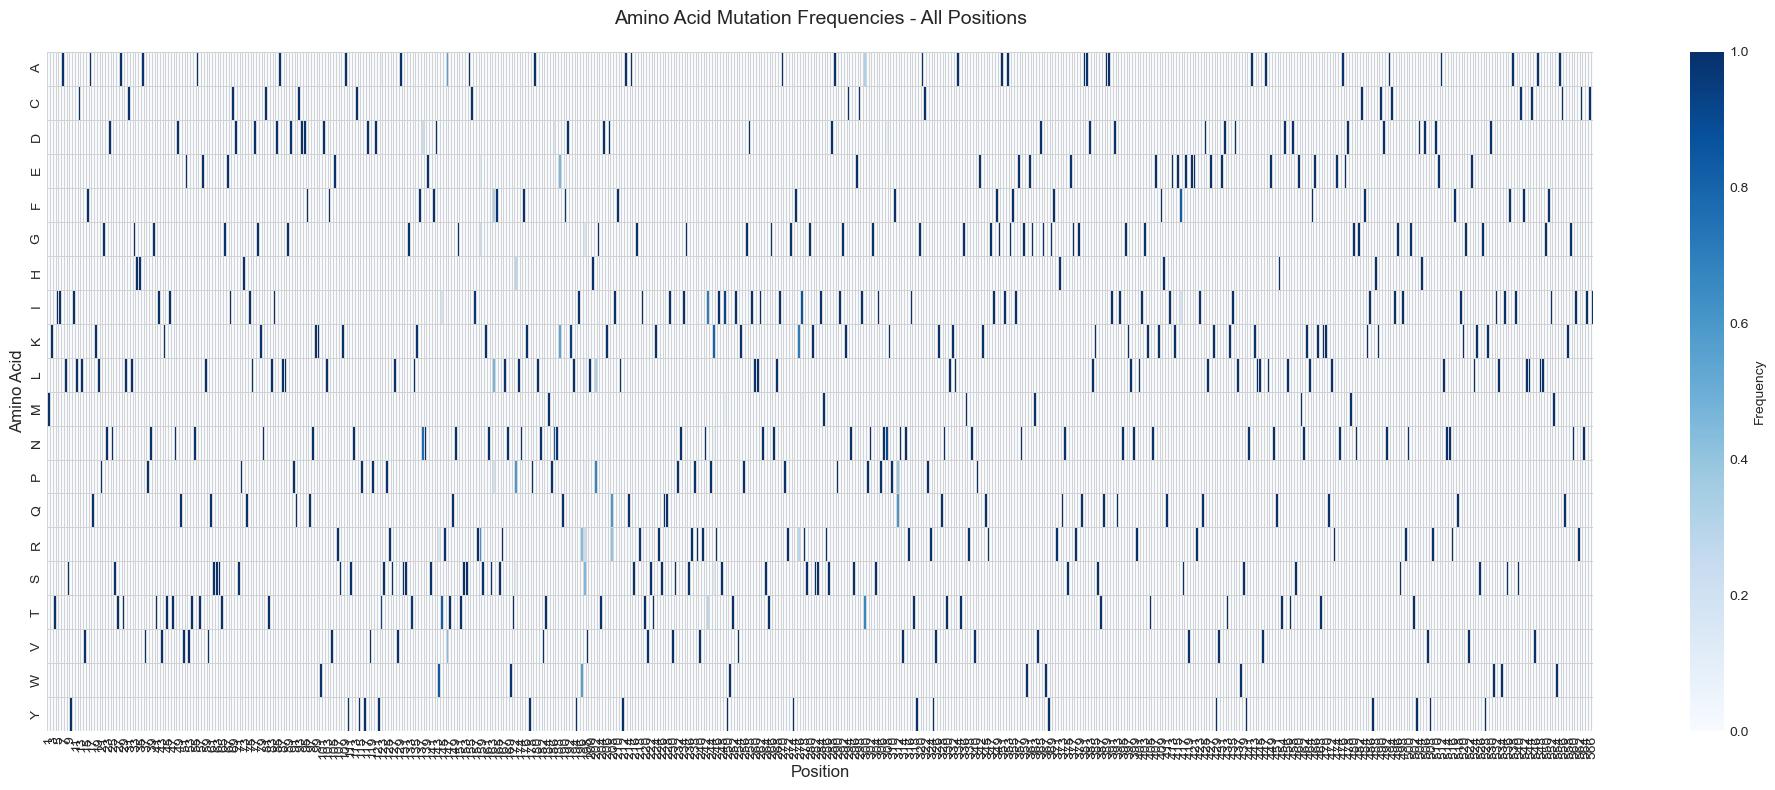

In [3]:
# Create basic heatmap
plot_mutation_heatmap(
    mutation_df,
    figsize=(20, 8),
    title="Amino Acid Mutation Frequencies - All Positions"
)

## 3. Filtered Heatmap - Minimum Frequency Threshold

Show only mutations that occur above a certain frequency threshold.

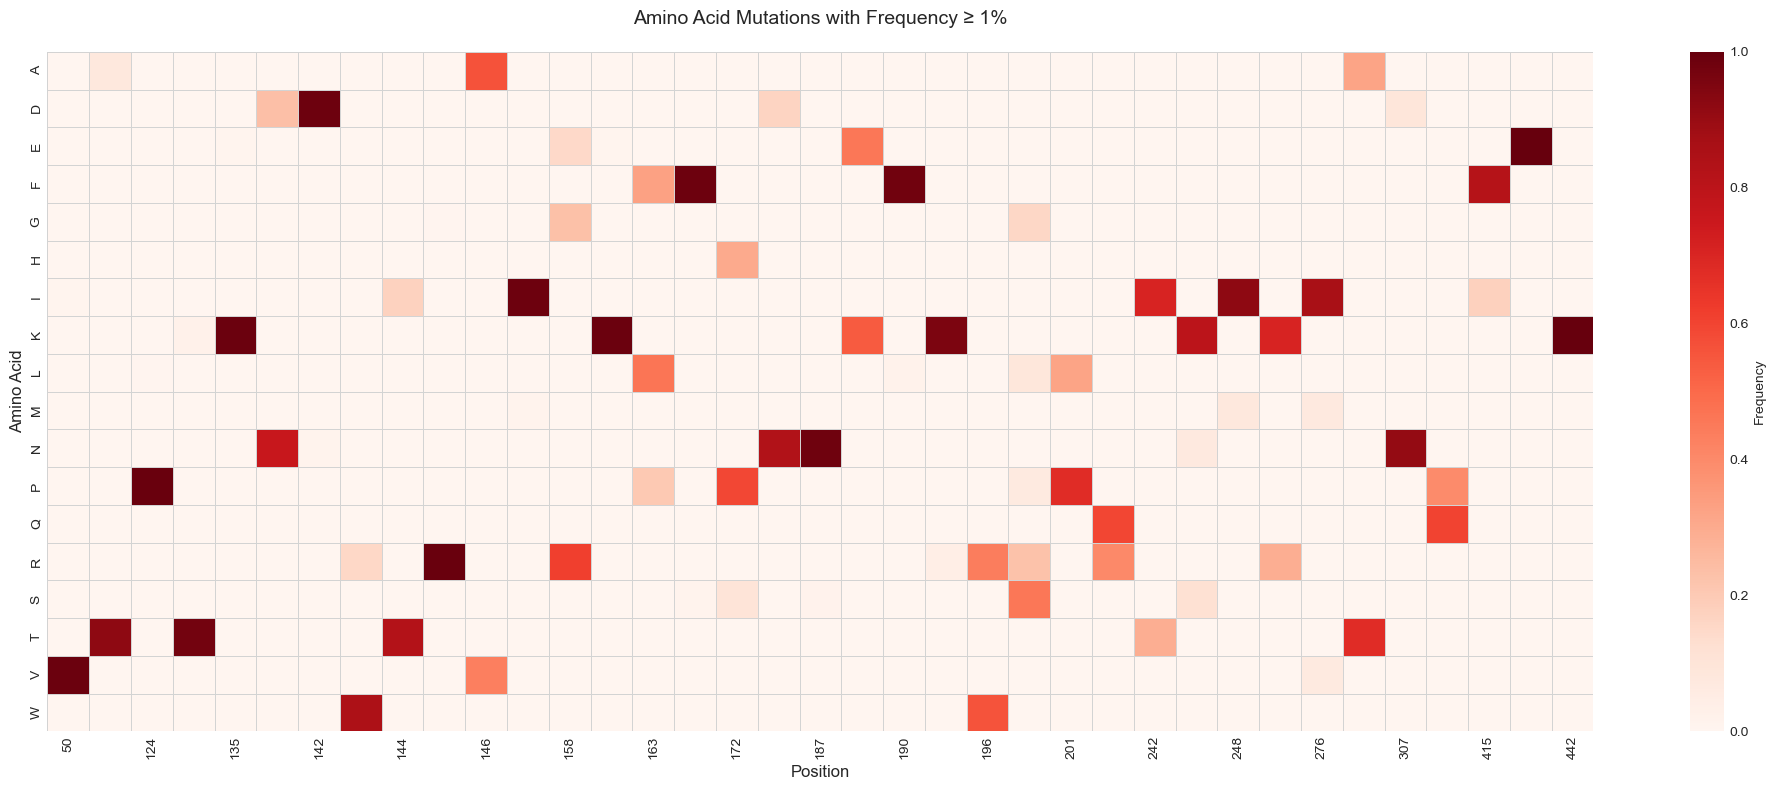

In [4]:
# Show only mutations with frequency >= 1%
plot_mutation_heatmap(
    mutation_df,
    min_frequency=0.01,
    figsize=(20, 8),
    title="Amino Acid Mutations with Frequency ≥ 1%",
    cmap='Reds'
)

## 3b. Mutation Counts Heatmap

Display raw mutation counts instead of frequencies.

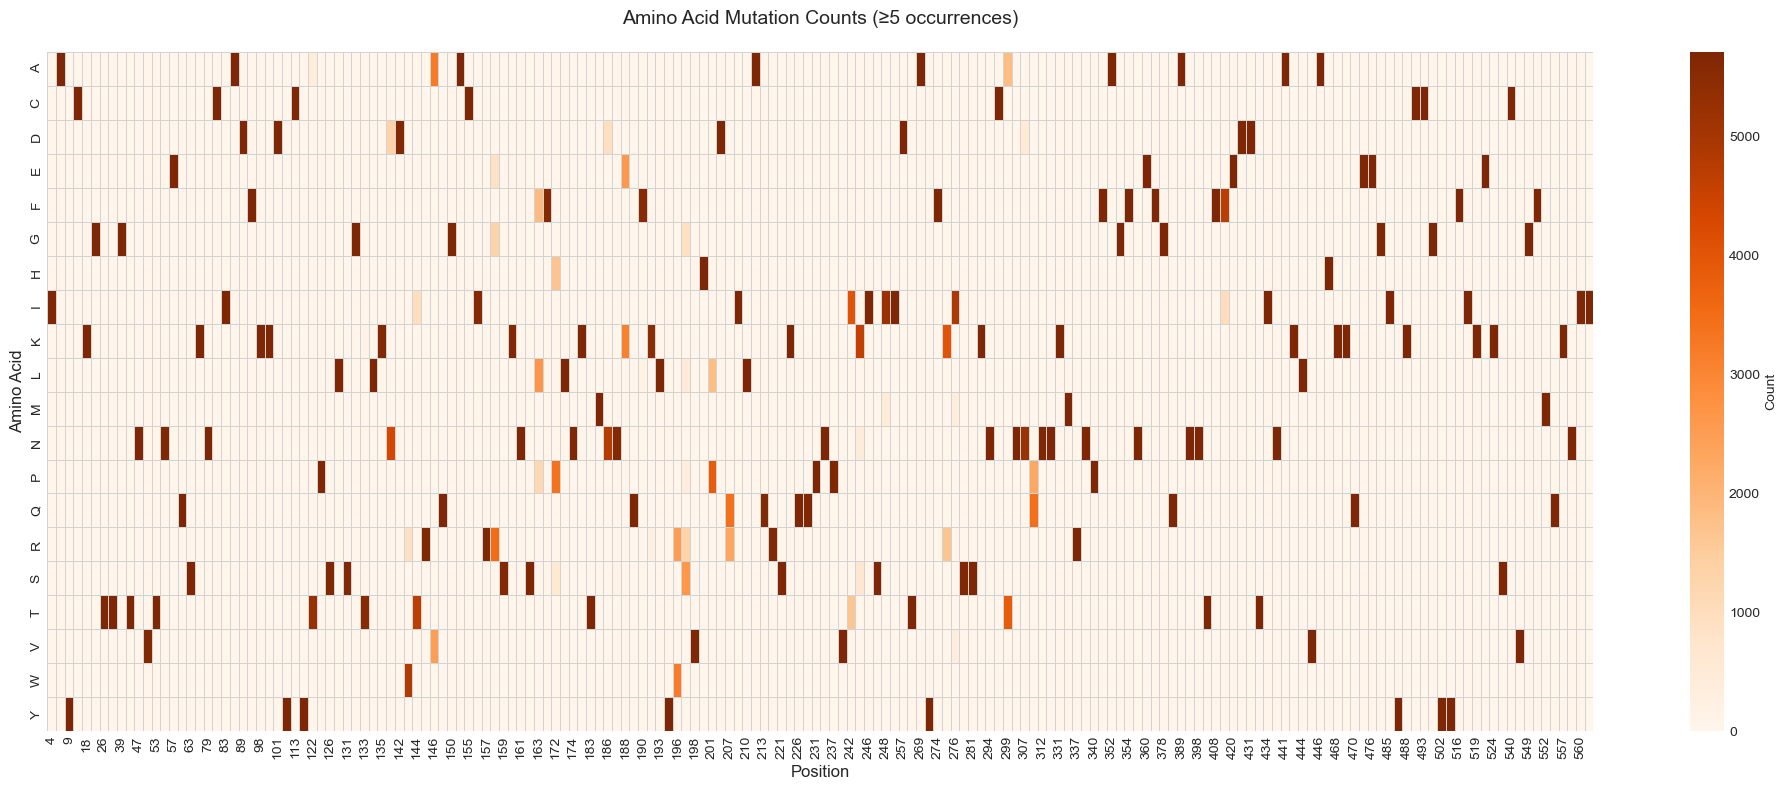

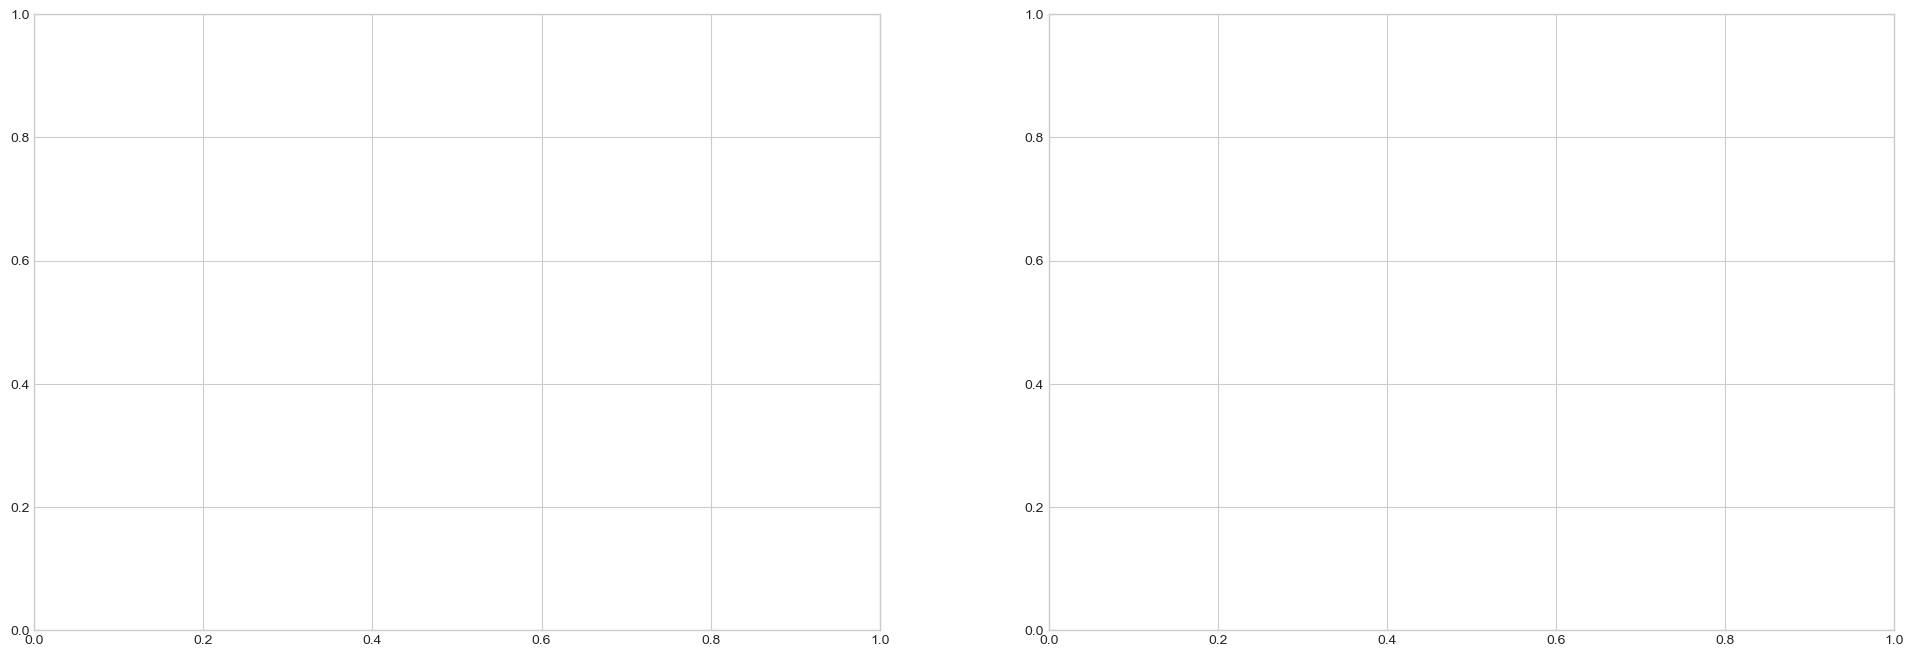

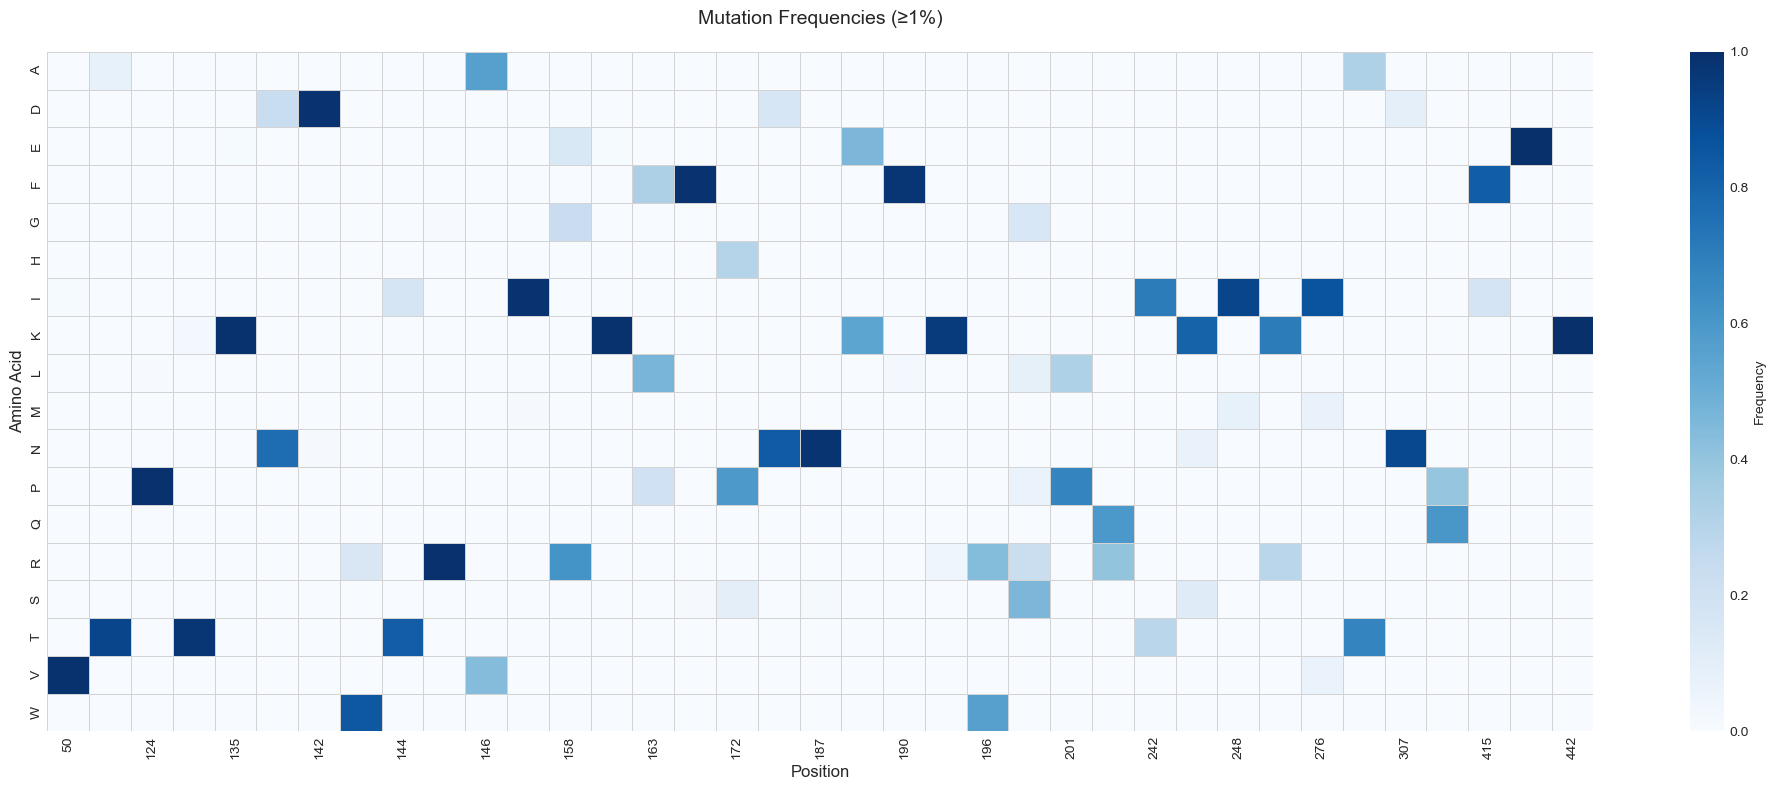

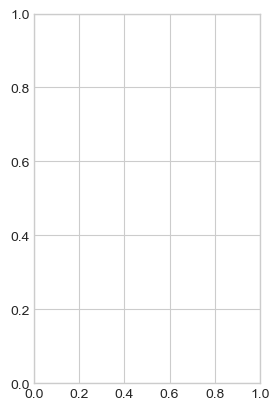

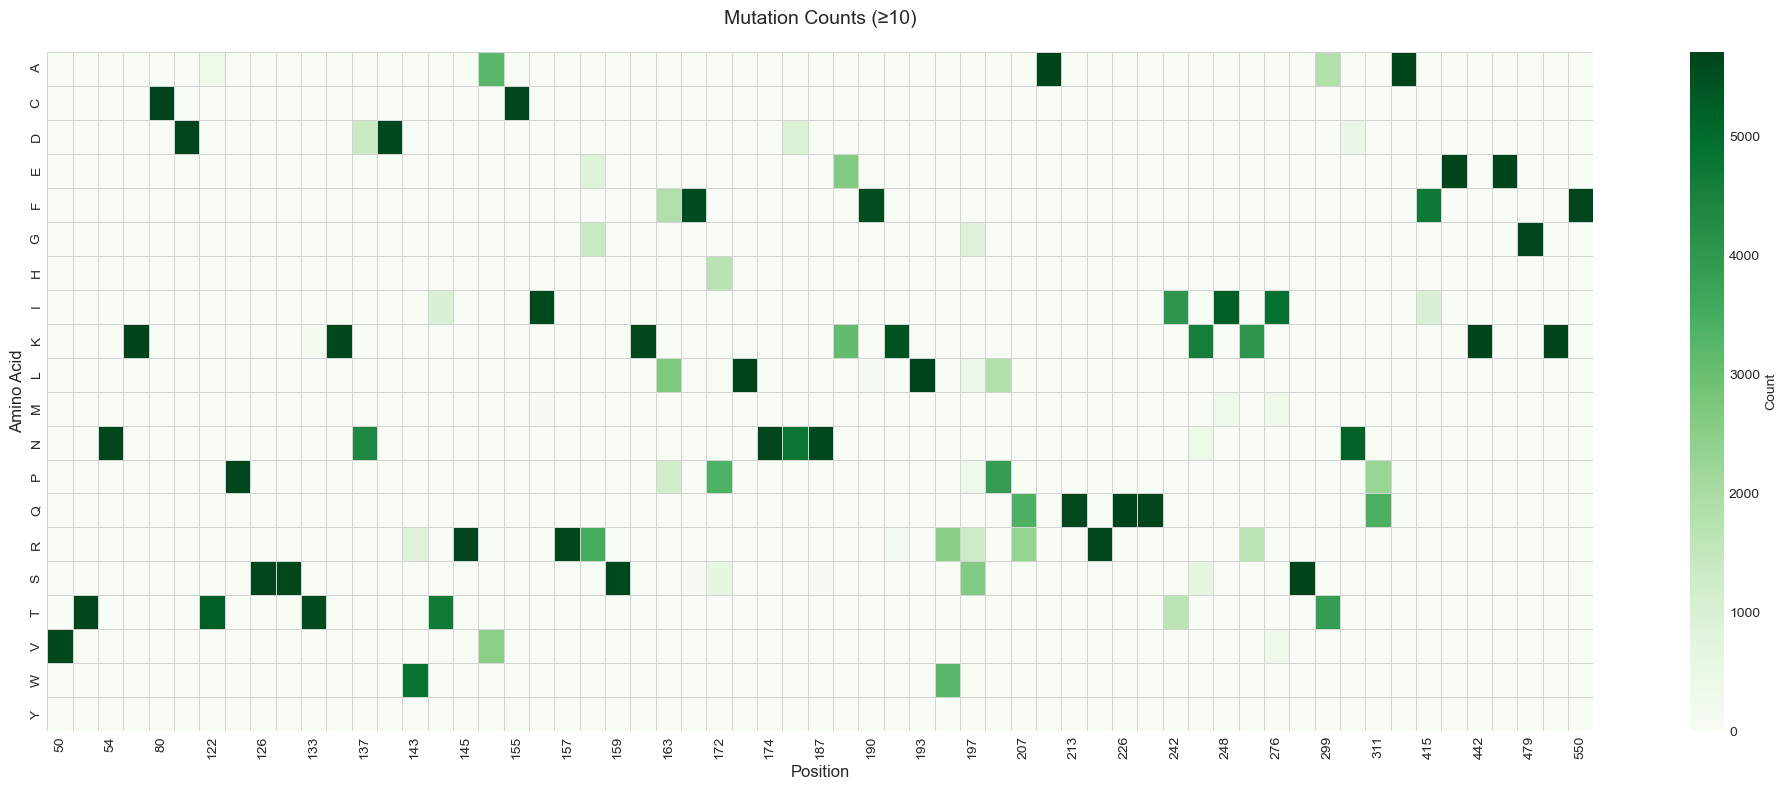

<Figure size 640x480 with 0 Axes>

In [5]:
# Show mutation counts instead of frequencies
plot_mutation_heatmap(
    mutation_df,
    plot_counts=True,
    min_count=5,  # Only show mutations that occur at least 5 times
    figsize=(20, 8),
    title="Amino Acid Mutation Counts (≥5 occurrences)",
    cmap='Oranges'
)

# Also create a side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

# Frequencies
plt.subplot(1, 2, 1)
plot_mutation_heatmap(
    mutation_df,
    min_frequency=0.01,
    title="Mutation Frequencies (≥1%)"
)

# Counts
plt.subplot(1, 2, 2)
plot_mutation_heatmap(
    mutation_df,
    plot_counts=True,
    min_count=10,
    title="Mutation Counts (≥10)",
    cmap='Greens'
)

plt.tight_layout()
plt.show()

## 4. Focus on Specific Region

Zoom in on a specific region of interest (e.g., antigenic sites).

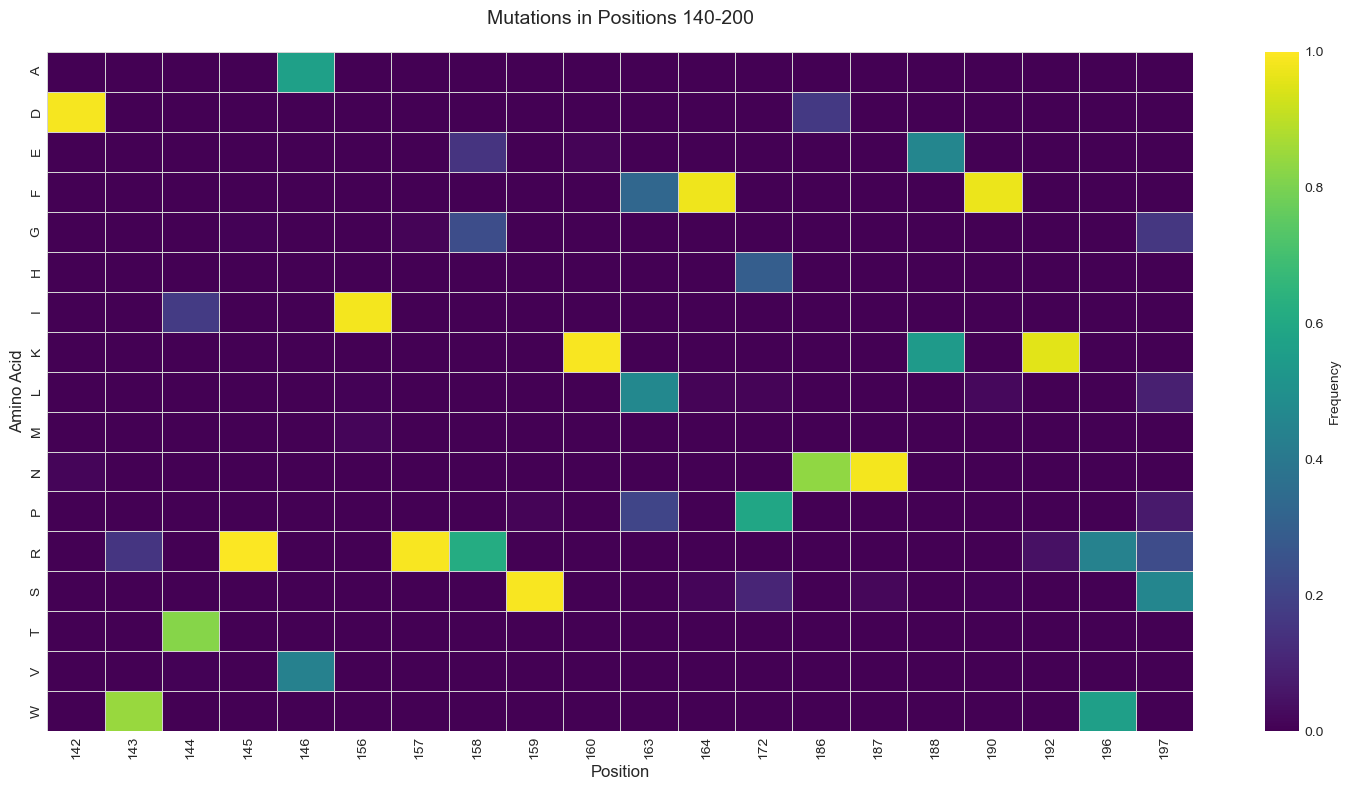

In [6]:
# Focus on positions 140-200 (example antigenic region)
plot_mutation_heatmap(
    mutation_df,
    positions=list(range(140, 201)),
    min_frequency=0.005,
    figsize=(15, 8),
    title="Mutations in Positions 140-200",
    cmap='viridis'
)

Loaded 48 epitope sites: [50, 53, 54, 121, 122, 124, 126, 131, 133, 135]...


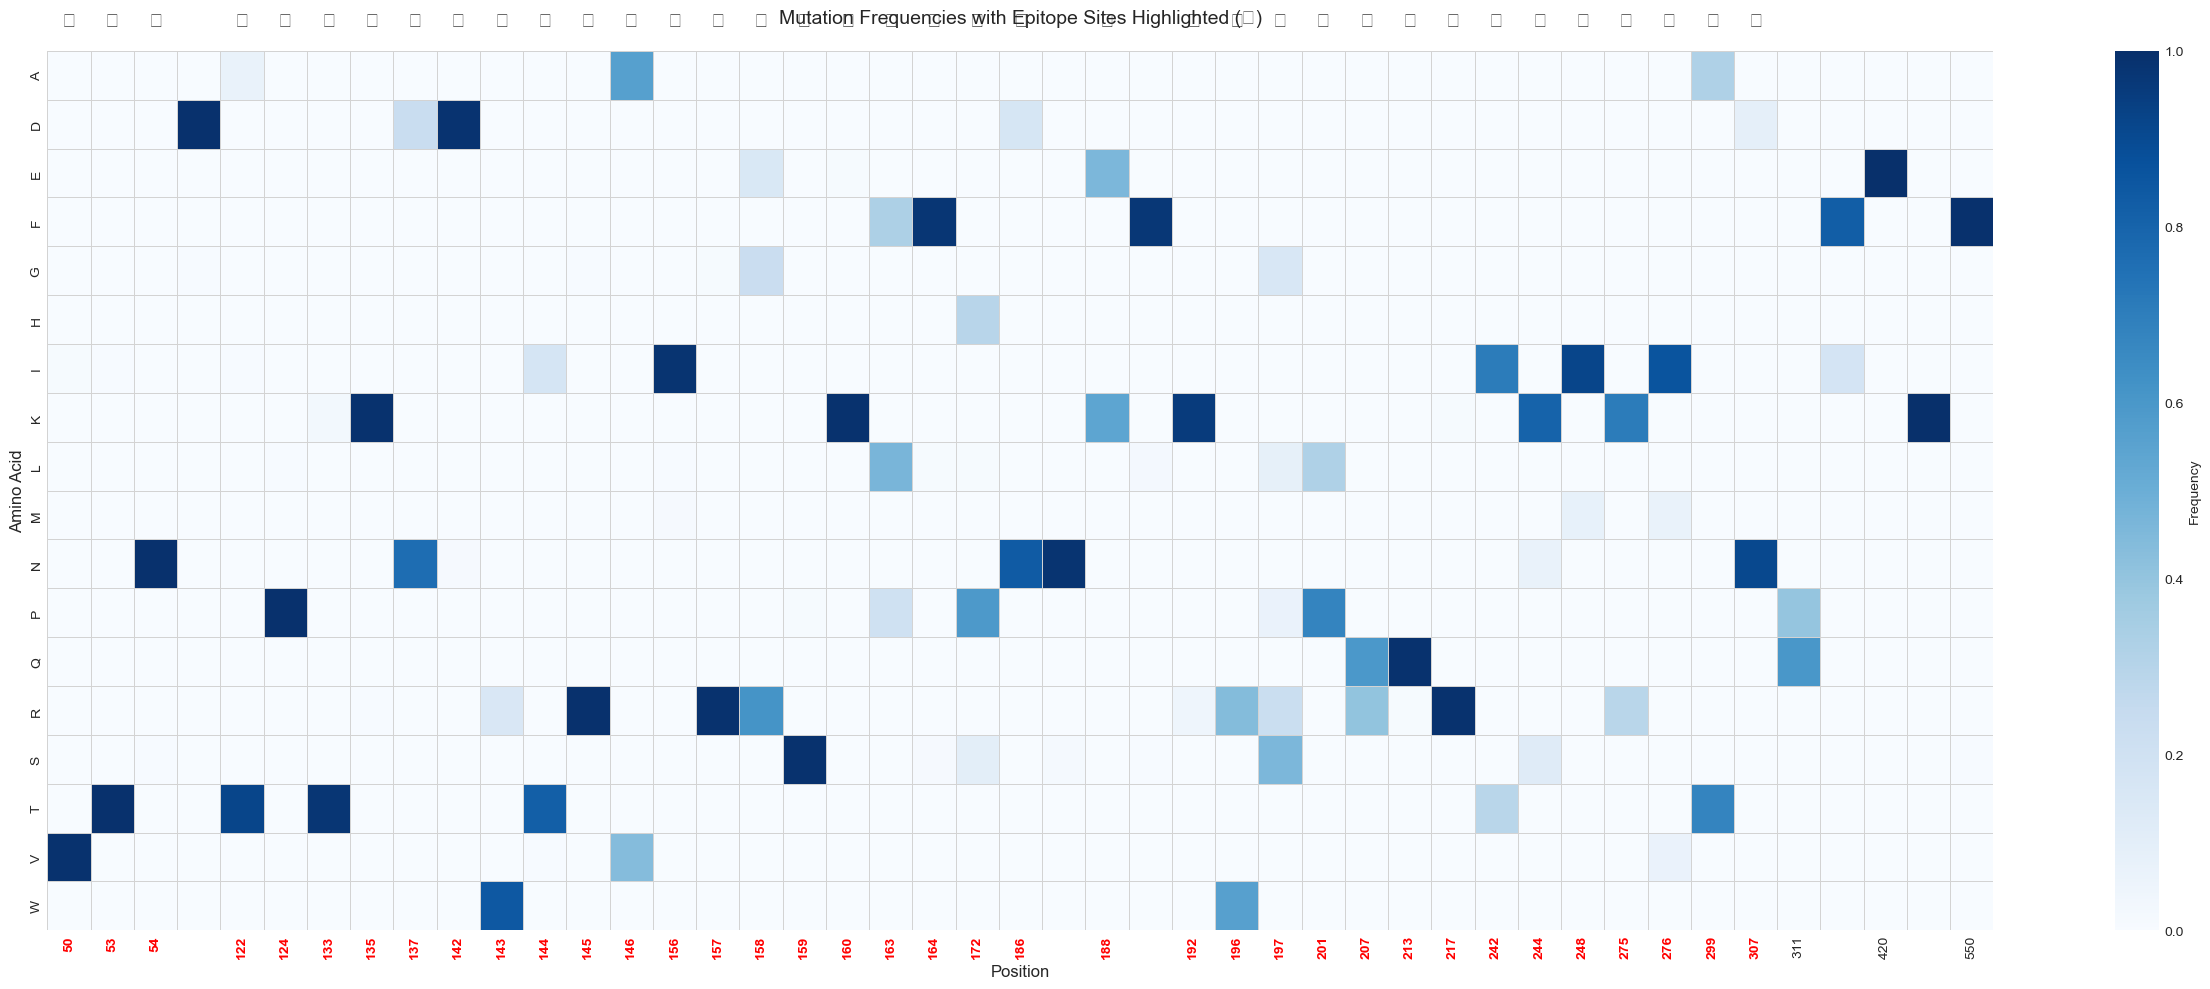

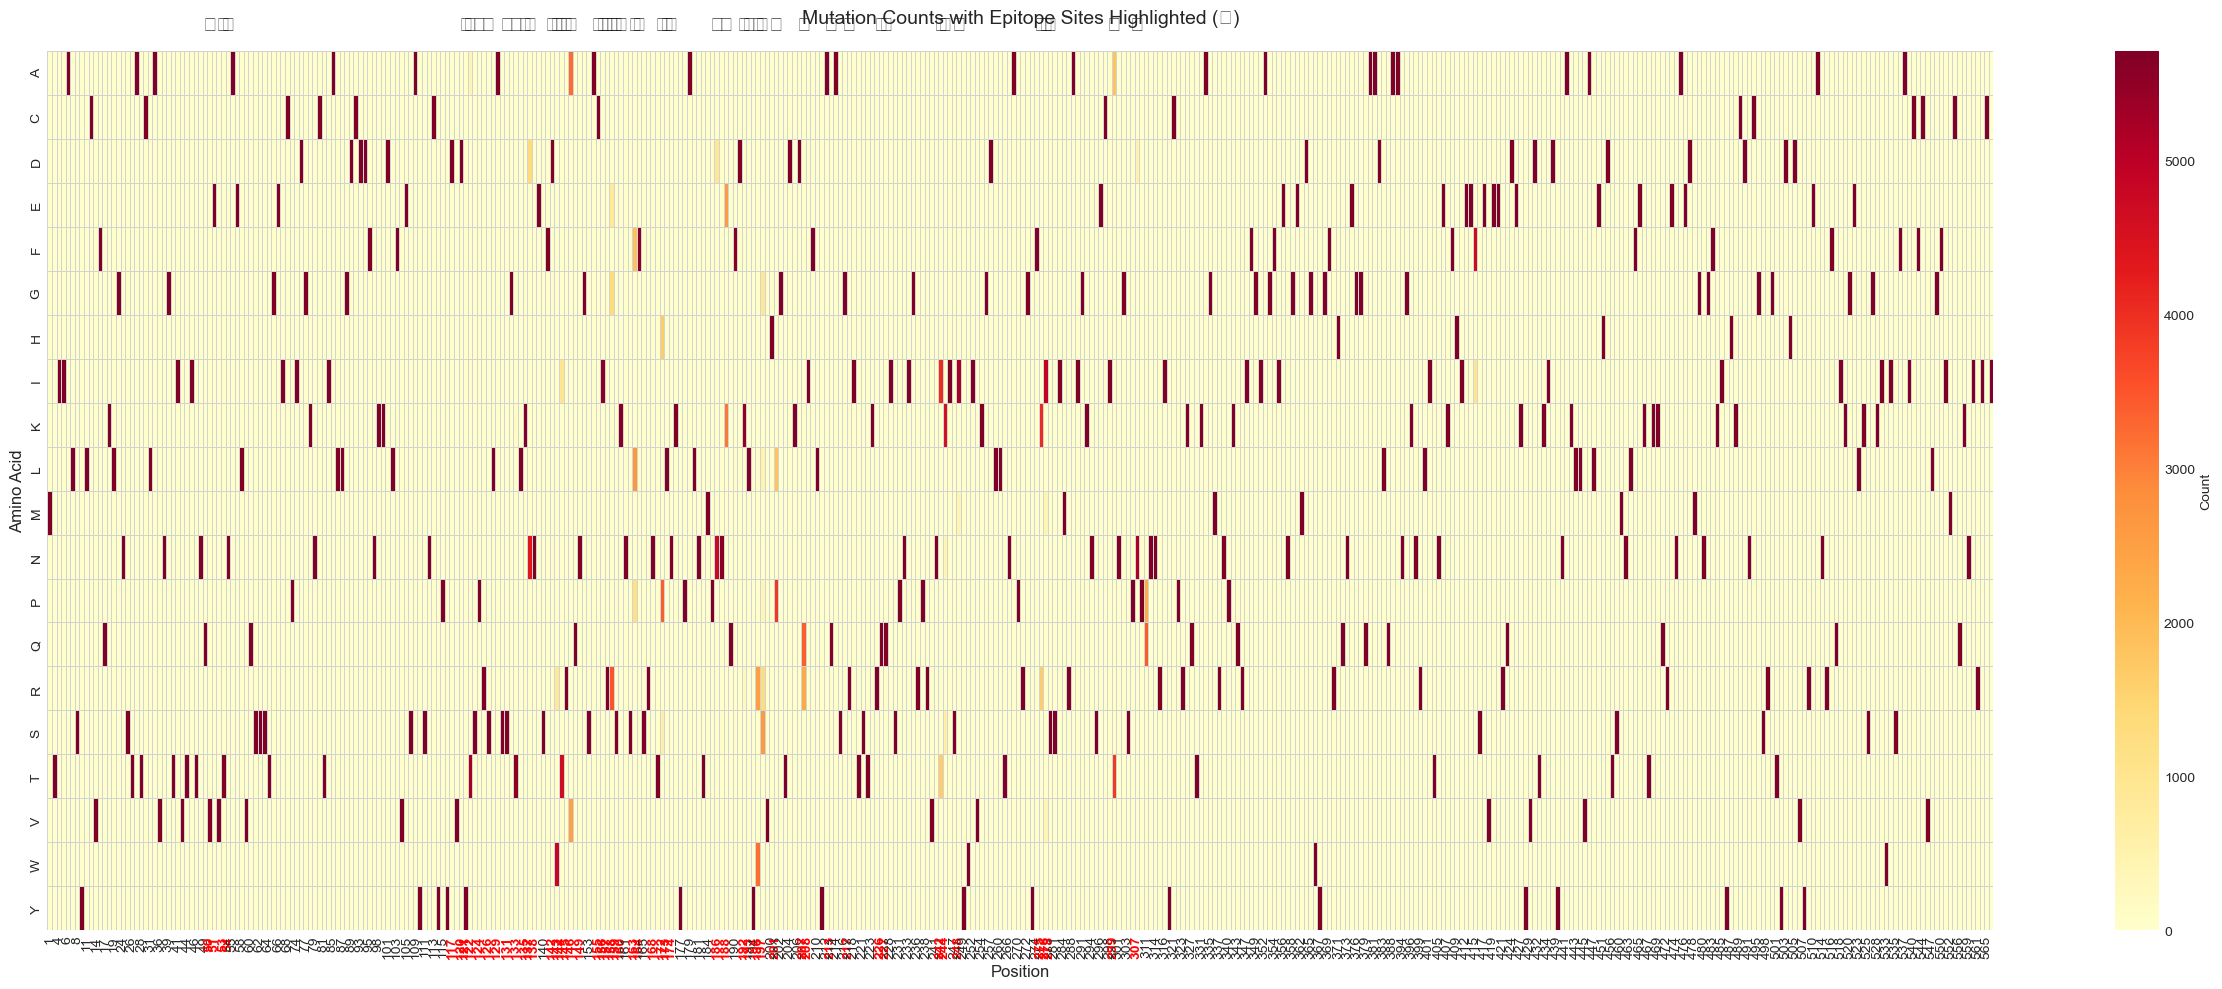

In [7]:
# Load epitope sites from file
epitope_file = "../data/flu-simulated-150k-samples/epitope_sites.txt"

# Read the epitope sites (comma-separated)
with open(epitope_file, 'r') as f:
    epitope_sites_str = f.read().strip()
    epitope_sites = [int(x.strip()) for x in epitope_sites_str.split(',')]

print(f"Loaded {len(epitope_sites)} epitope sites: {epitope_sites[:10]}...")

# Create heatmap with epitope sites highlighted
plot_mutation_heatmap(
    mutation_df,
    min_frequency=0.005,
    figsize=(25, 10),
    title="Mutation Frequencies with Epitope Sites Highlighted (★)",
    highlight_positions=epitope_sites
)

# Also create a counts version
plot_mutation_heatmap(
    mutation_df,
    plot_counts=True,
    min_count=3,
    figsize=(25, 10),
    title="Mutation Counts with Epitope Sites Highlighted (★)",
    highlight_positions=epitope_sites,
    cmap='YlOrRd'
)

Loaded 48 epitope sites: [50, 53, 54, 121, 122, 124, 126, 131, 133, 135]...


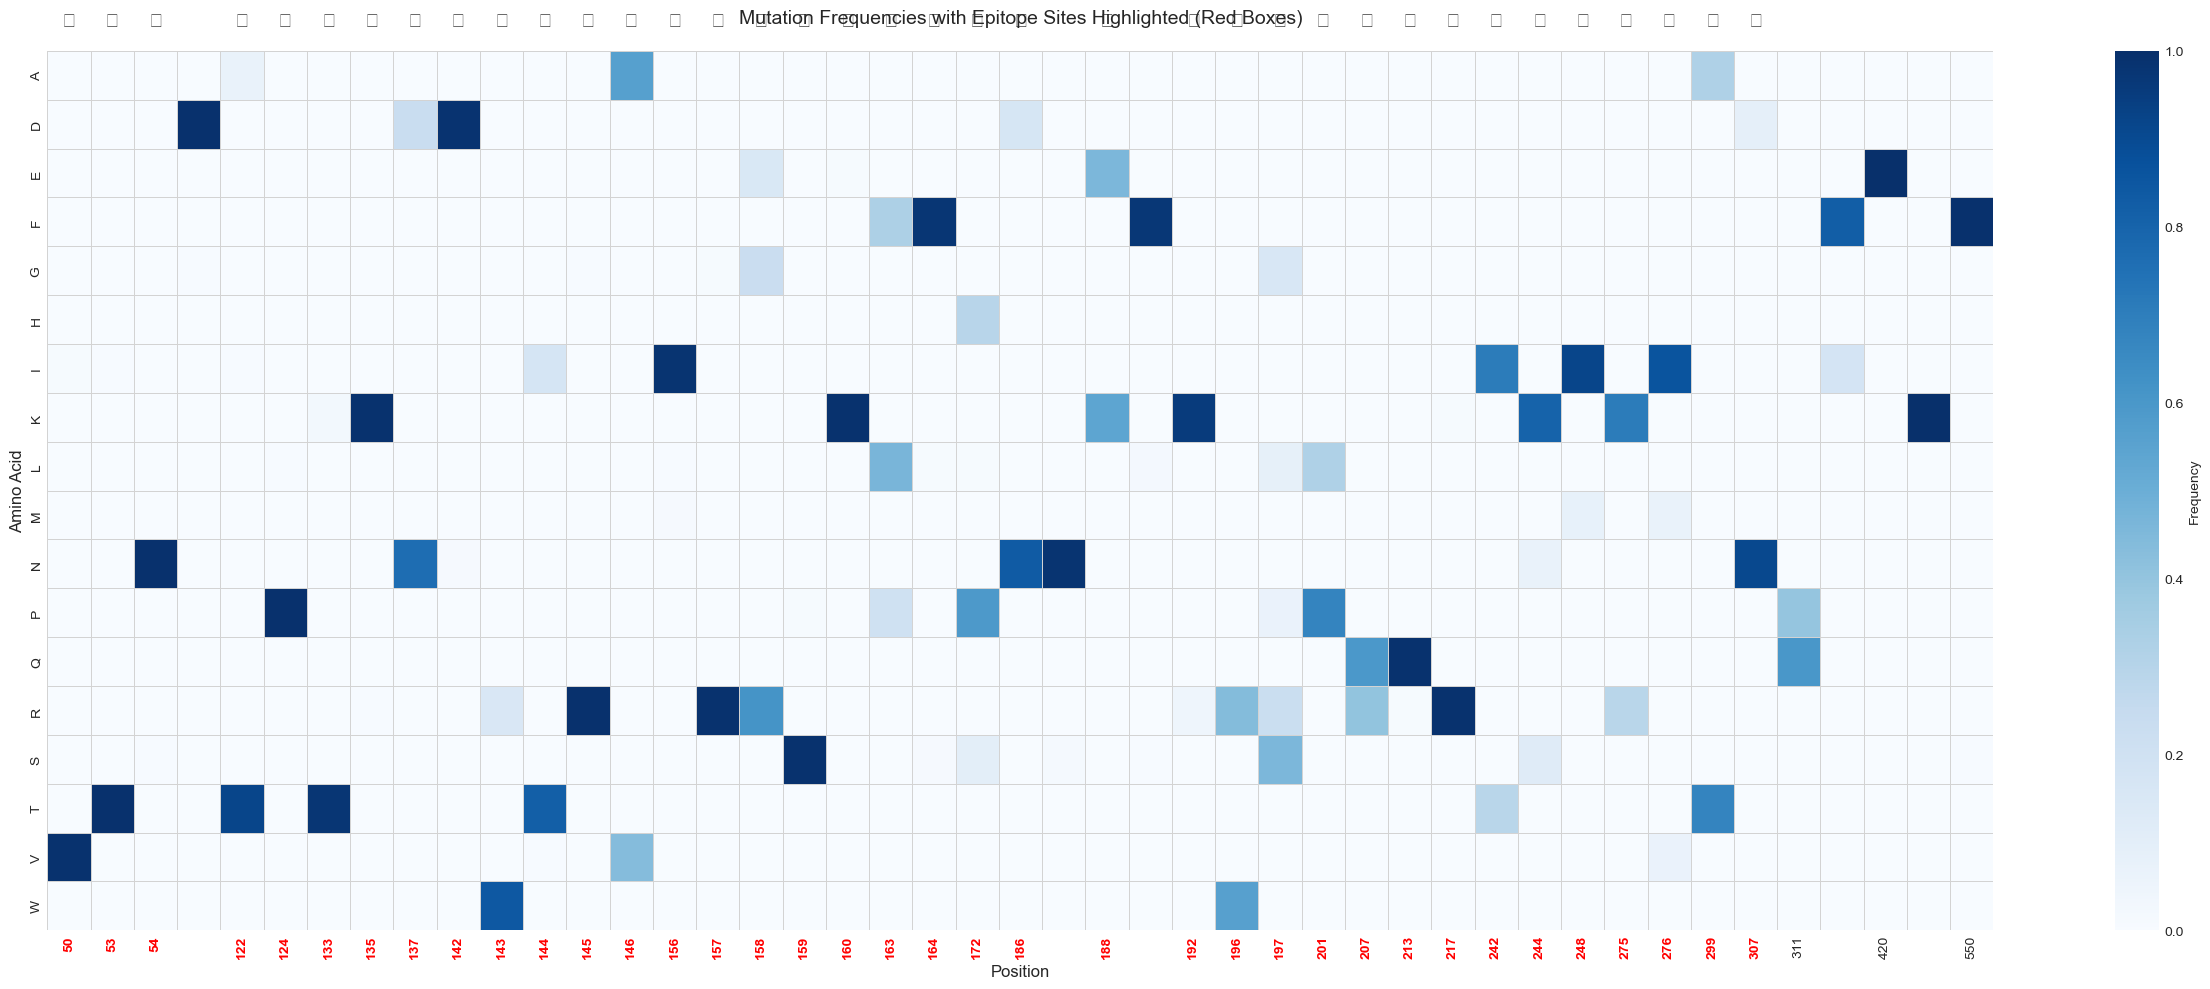

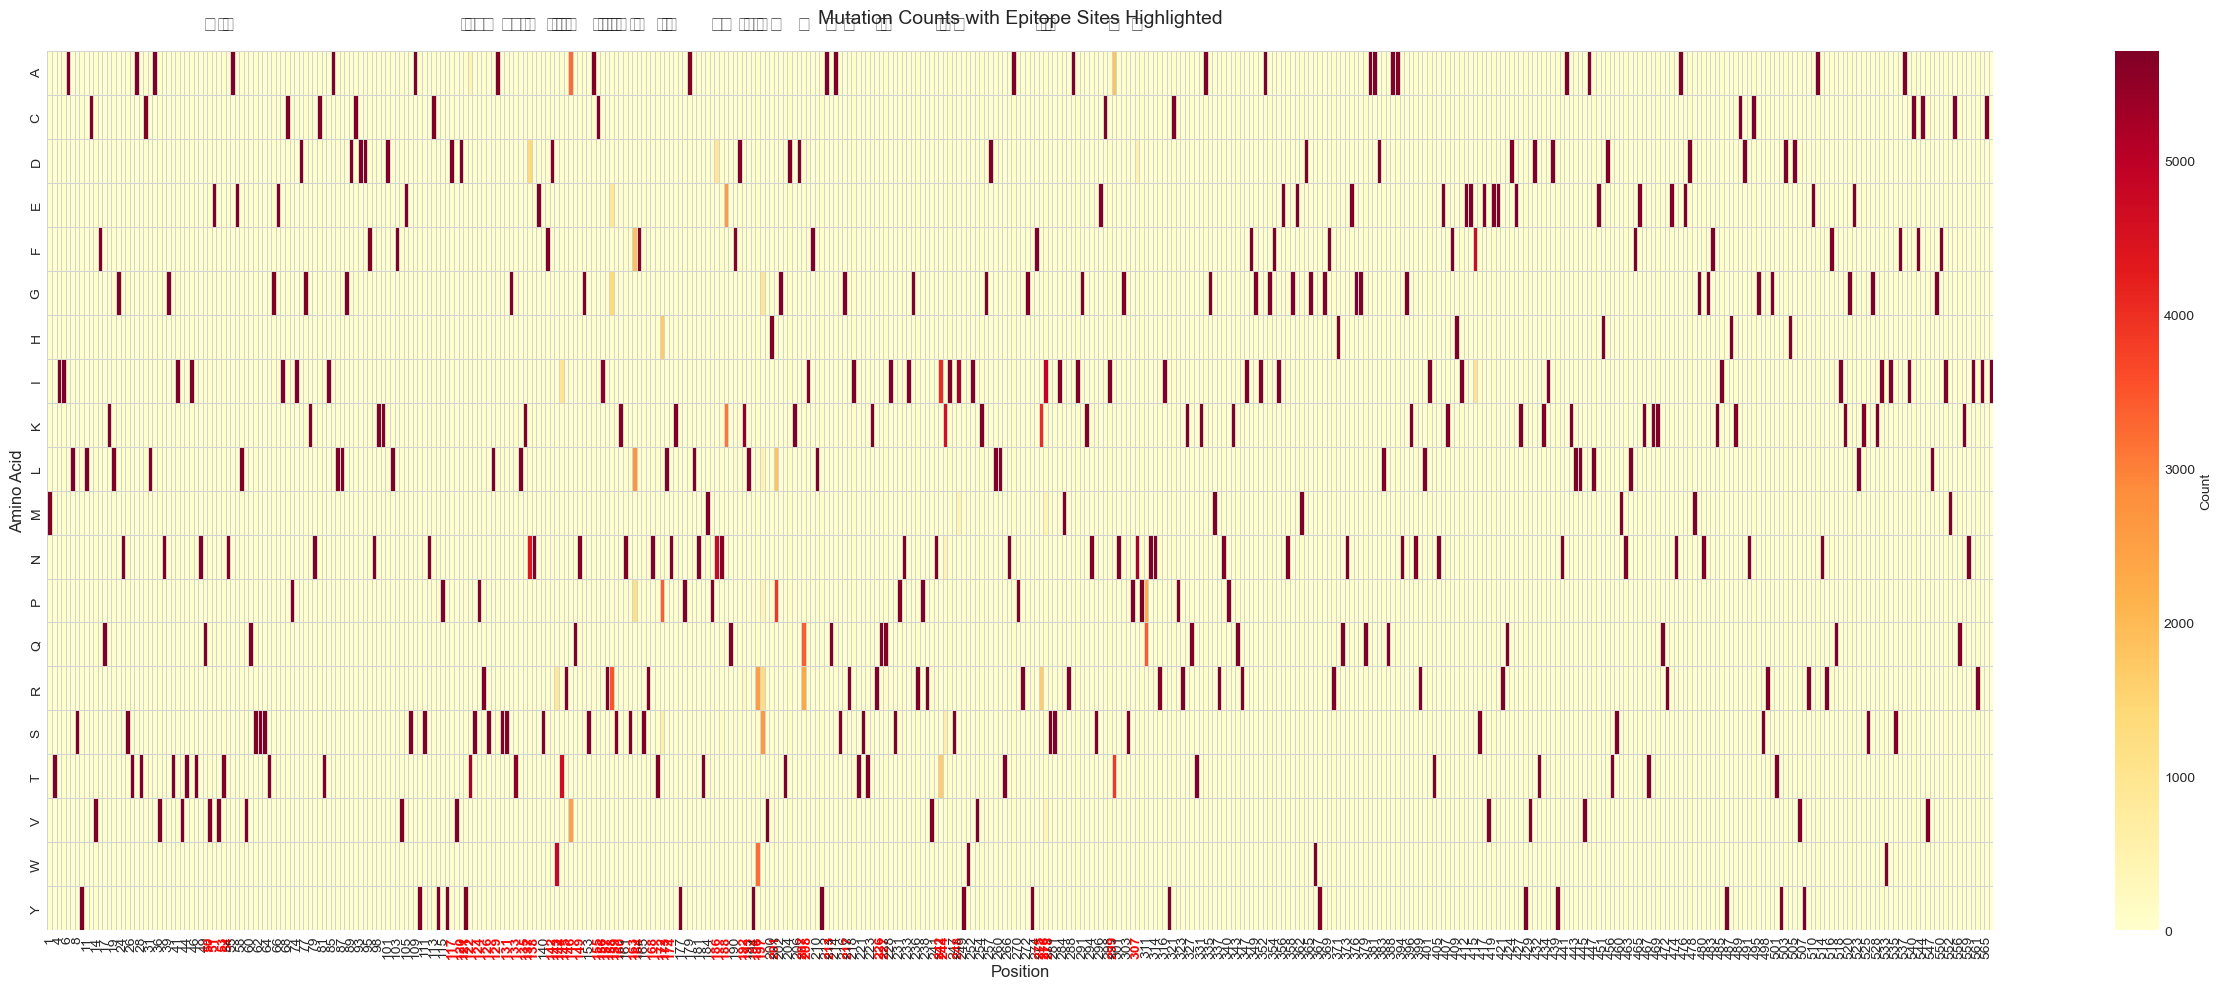

In [8]:
# Load epitope sites from file
epitope_file = "../data/flu-simulated-150k-samples/epitope_sites.txt"

# Read the epitope sites (comma-separated)
with open(epitope_file, 'r') as f:
    epitope_sites_str = f.read().strip()
    epitope_sites = [int(x.strip()) for x in epitope_sites_str.split(',')]

print(f"Loaded {len(epitope_sites)} epitope sites: {epitope_sites[:10]}...")

# Create heatmap with epitope sites highlighted
plot_mutation_heatmap(
    mutation_df,
    min_frequency=0.005,
    figsize=(25, 10),
    title="Mutation Frequencies with Epitope Sites Highlighted (Red Boxes)",
    highlight_positions=epitope_sites,
)

# Also create a counts version
plot_mutation_heatmap(
    mutation_df,
    plot_counts=True,
    min_count=3,
    figsize=(25, 10),
    title="Mutation Counts with Epitope Sites Highlighted",
    highlight_positions=epitope_sites,
    cmap='YlOrRd'
)

## 4c. Quantitative Analysis of Epitope Site Mutations

Analyze whether mutations are enriched at epitope sites compared to non-epitope sites.

In [9]:
# Analyze mutation enrichment at epitope sites
epitope_mutations = mutation_df[mutation_df['position'].isin(epitope_sites)]
non_epitope_mutations = mutation_df[~mutation_df['position'].isin(epitope_sites)]

# Calculate statistics
n_epitope_positions = len(epitope_sites)
n_total_positions = mutation_df['position'].nunique()
n_non_epitope_positions = n_total_positions - n_epitope_positions

print("=== Epitope Site Analysis ===")
print(f"Total epitope sites: {n_epitope_positions}")
print(f"Total positions with mutations: {n_total_positions}")
print(f"Non-epitope positions: {n_non_epitope_positions}")
print()

# Mutation counts and frequencies
epitope_total_mutations = len(epitope_mutations)
non_epitope_total_mutations = len(non_epitope_mutations)
epitope_total_frequency = epitope_mutations['frequency'].sum()
non_epitope_total_frequency = non_epitope_mutations['frequency'].sum()

print("=== Mutation Summary ===")
print(f"Mutations at epitope sites: {epitope_total_mutations}")
print(f"Mutations at non-epitope sites: {non_epitope_total_mutations}")
print(f"Total frequency at epitope sites: {epitope_total_frequency:.3f}")
print(f"Total frequency at non-epitope sites: {non_epitope_total_frequency:.3f}")
print()

# Calculate enrichment ratios
mutations_per_epitope_site = epitope_total_mutations / n_epitope_positions if n_epitope_positions > 0 else 0
mutations_per_non_epitope_site = non_epitope_total_mutations / n_non_epitope_positions if n_non_epitope_positions > 0 else 0
enrichment_ratio = mutations_per_epitope_site / mutations_per_non_epitope_site if mutations_per_non_epitope_site > 0 else float('inf')

print("=== Enrichment Analysis ===")
print(f"Average mutations per epitope site: {mutations_per_epitope_site:.2f}")
print(f"Average mutations per non-epitope site: {mutations_per_non_epitope_site:.2f}")
print(f"Enrichment ratio (epitope/non-epitope): {enrichment_ratio:.2f}x")
print()

if enrichment_ratio > 1:
    print(f"✓ Mutations are {enrichment_ratio:.1f}x more frequent at epitope sites!")
else:
    print(f"⚠ Mutations are {1/enrichment_ratio:.1f}x less frequent at epitope sites")

# Top mutated epitope sites
print("\n=== Top 10 Most Mutated Epitope Sites ===")
epitope_site_summary = epitope_mutations.groupby('position').agg({
    'frequency': 'sum',
    'count': 'sum',
    'variant_aa': 'count'
}).round(3)
epitope_site_summary.columns = ['total_frequency', 'total_count', 'n_mutations']
epitope_site_summary = epitope_site_summary.sort_values('total_frequency', ascending=False)
print(epitope_site_summary.head(10))

=== Epitope Site Analysis ===
Total epitope sites: 48
Total positions with mutations: 563
Non-epitope positions: 515

=== Mutation Summary ===
Mutations at epitope sites: 254
Mutations at non-epitope sites: 1382
Total frequency at epitope sites: 14.751
Total frequency at non-epitope sites: 3.188

=== Enrichment Analysis ===
Average mutations per epitope site: 5.29
Average mutations per non-epitope site: 2.68
Enrichment ratio (epitope/non-epitope): 1.97x

✓ Mutations are 2.0x more frequent at epitope sites!

=== Top 10 Most Mutated Epitope Sites ===
          total_frequency  total_count  n_mutations
position                                           
135                 0.999         5709            4
50                  0.998         5700            4
145                 0.998         5702            3
124                 0.997         5699            5
142                 0.991         5665            5
122                 0.928         5301            6
307                 0.910    

## 5. Comparing Consensus vs Reference Sequence

Compare mutation patterns when using consensus sequence vs the provided reference sequence.

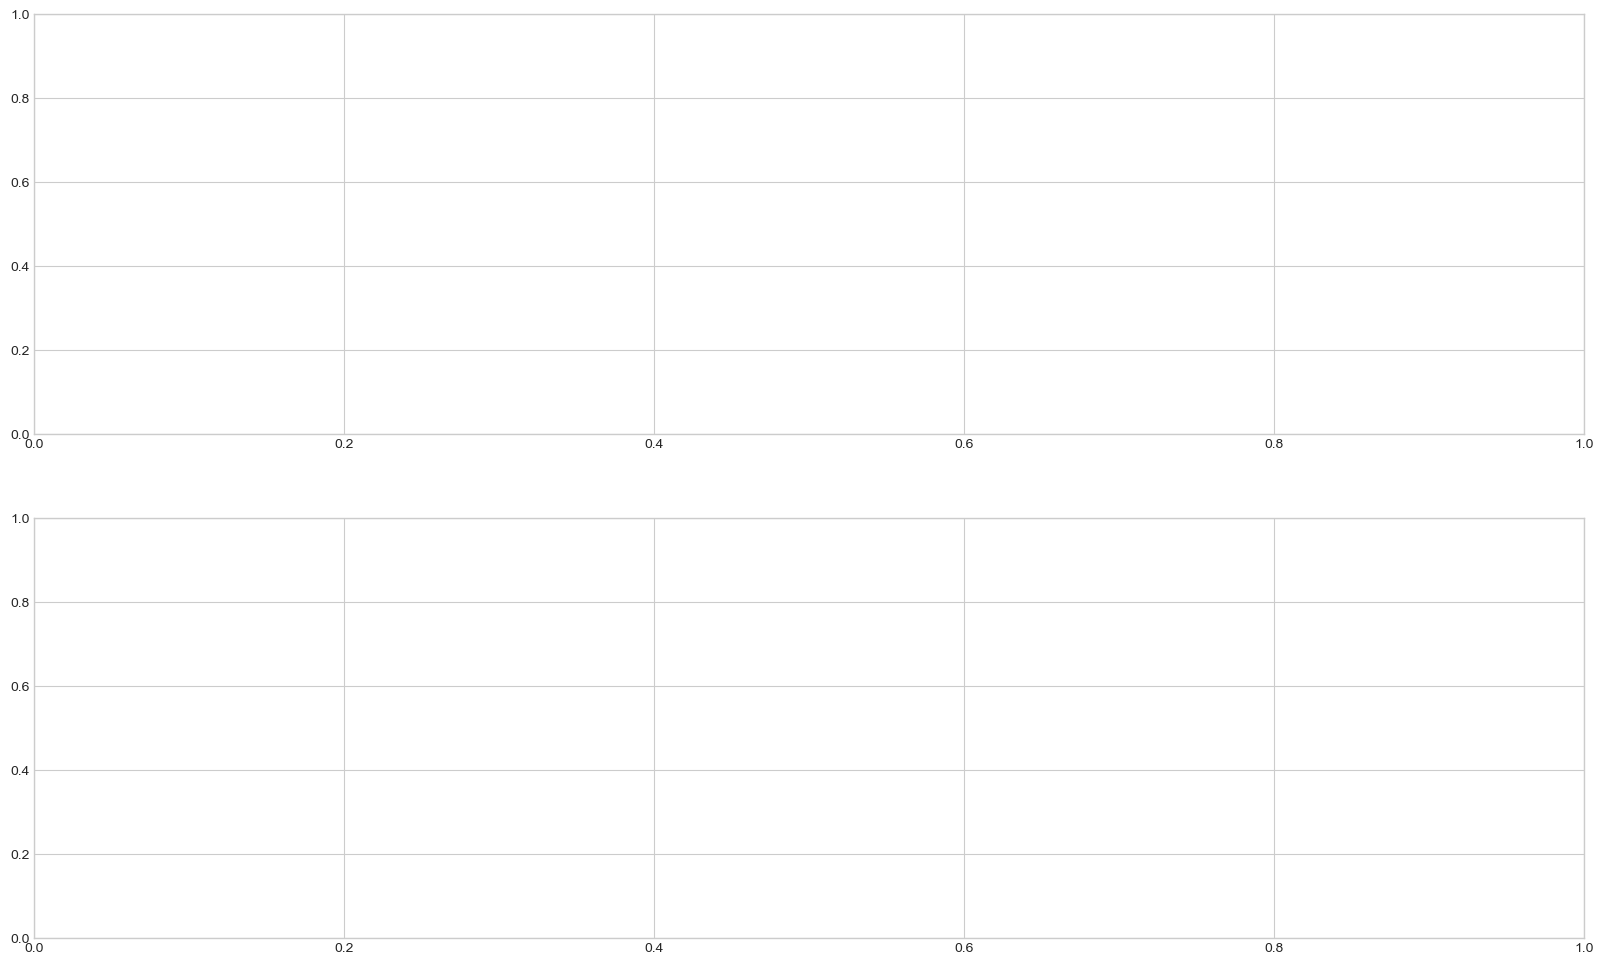

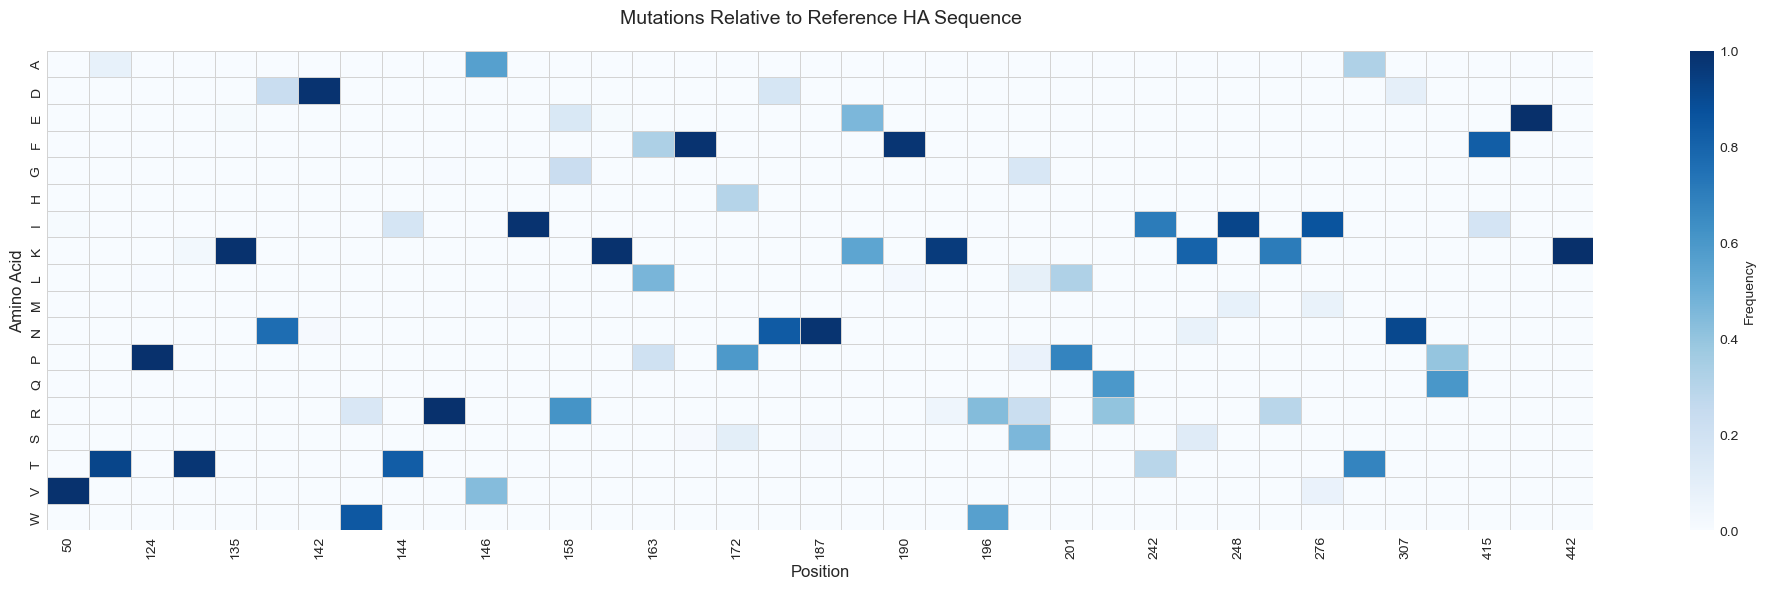

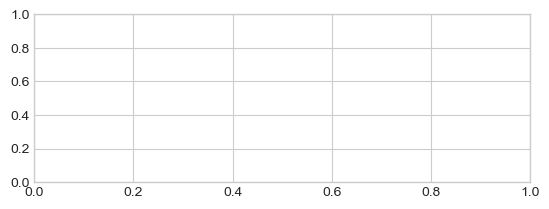

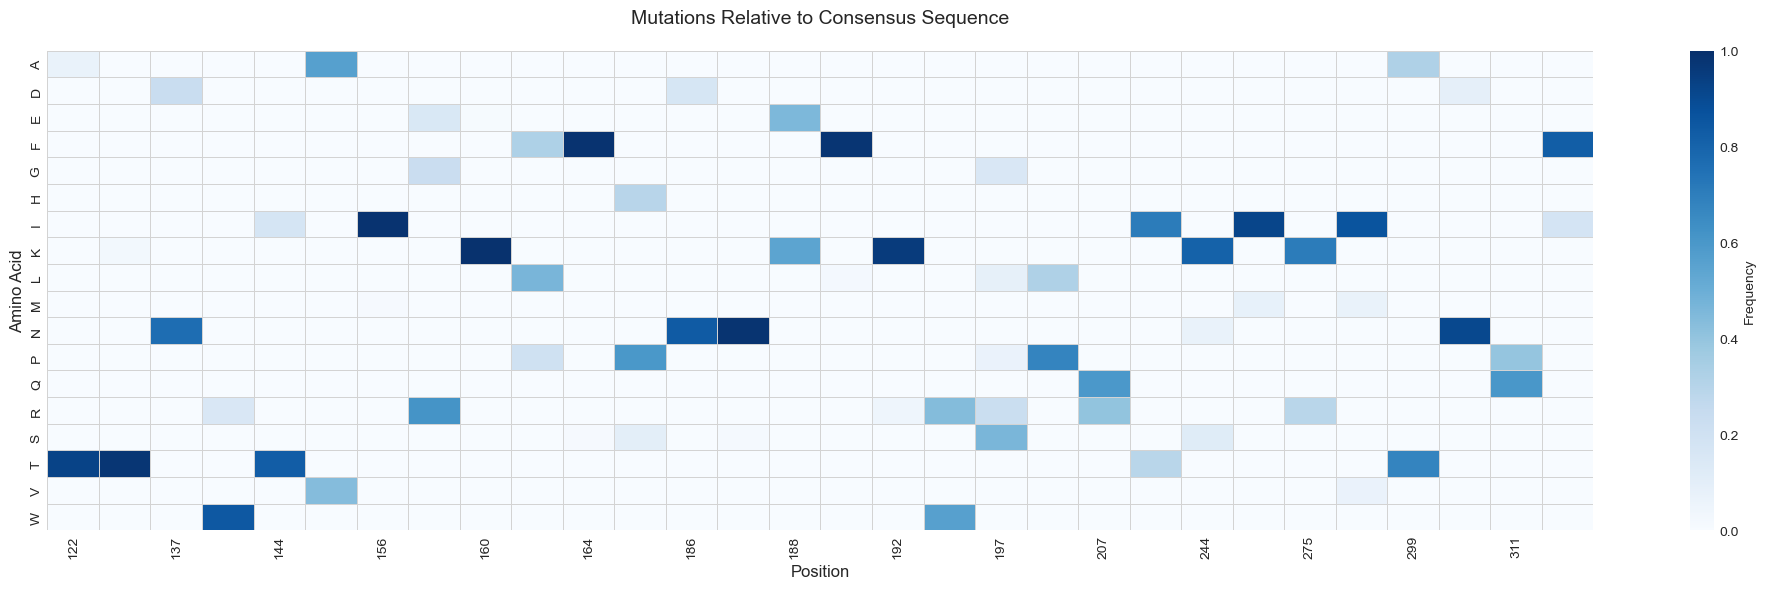

Mutations found using reference sequence: 1636
Mutations found using consensus sequence: 1637


<Figure size 640x480 with 0 Axes>

In [10]:
# Calculate mutations using consensus as reference
mutation_df_consensus = reader.fasta_to_aa_mutations(fasta_file)

# Create comparison plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12))

# Plot with reference sequence
plt.subplot(2, 1, 1)
plot_mutation_heatmap(
    mutation_df,
    min_frequency=0.01,
    figsize=(20, 6),
    title="Mutations Relative to Reference HA Sequence"
)

# Plot with consensus sequence
plt.subplot(2, 1, 2)
plot_mutation_heatmap(
    mutation_df_consensus,
    min_frequency=0.01,
    figsize=(20, 6),
    title="Mutations Relative to Consensus Sequence"
)

plt.tight_layout()

# Compare the number of mutations detected
print(f"Mutations found using reference sequence: {len(mutation_df)}")
print(f"Mutations found using consensus sequence: {len(mutation_df_consensus)}")

## 6. Summary Statistics

Analyze the mutation data to identify hotspots and conserved regions.

Top 10 most variable positions:
          total_mut_freq  n_mutations  n_variants
position                                         
420                0.999            3           3
442                0.999            1           1
135                0.999            4           4
145                0.998            3           3
50                 0.998            4           4
124                0.997            5           5
142                0.991            5           5
122                0.928            6           6
307                0.910            7           7
244                0.882            8           8


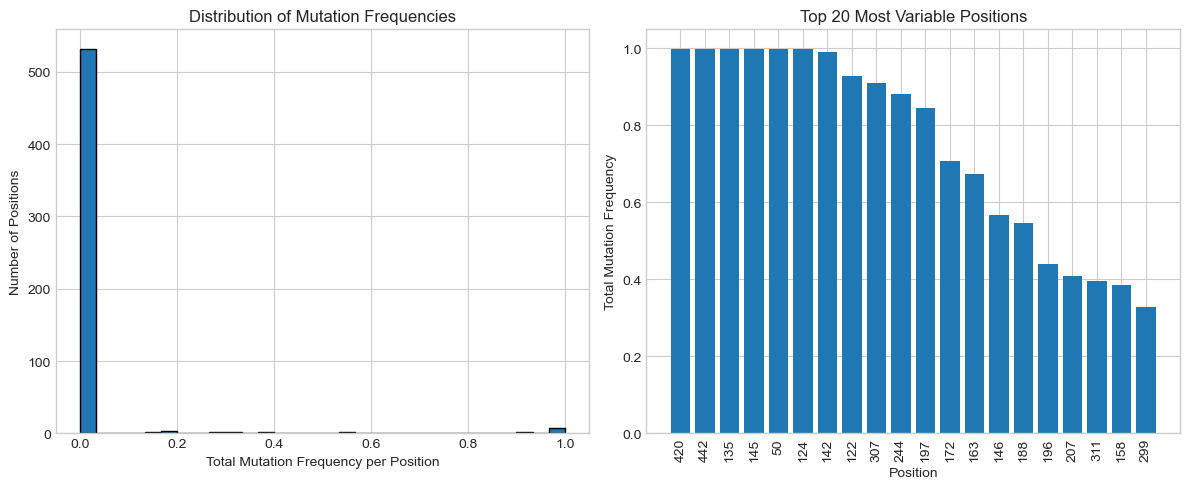

In [11]:
# Calculate mutation statistics by position
position_stats = mutation_df.groupby('position').agg({
    'frequency': ['sum', 'count'],
    'variant_aa': 'nunique'
}).round(3)

position_stats.columns = ['total_mut_freq', 'n_mutations', 'n_variants']
position_stats = position_stats.sort_values('total_mut_freq', ascending=False)

print("Top 10 most variable positions:")
print(position_stats.head(10))

# Plot mutation frequency distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(position_stats['total_mut_freq'], bins=30, edgecolor='black')
plt.xlabel('Total Mutation Frequency per Position')
plt.ylabel('Number of Positions')
plt.title('Distribution of Mutation Frequencies')

plt.subplot(1, 2, 2)
top_positions = position_stats.head(20)
plt.bar(range(len(top_positions)), top_positions['total_mut_freq'])
plt.xticks(range(len(top_positions)), top_positions.index, rotation=90)
plt.xlabel('Position')
plt.ylabel('Total Mutation Frequency')
plt.title('Top 20 Most Variable Positions')

plt.tight_layout()
plt.show()

## 7. Export Results

Save the mutation data and visualizations for further analysis.

Mutation data saved to mutation_frequencies.csv
Figure saved to mutation_heatmap.png


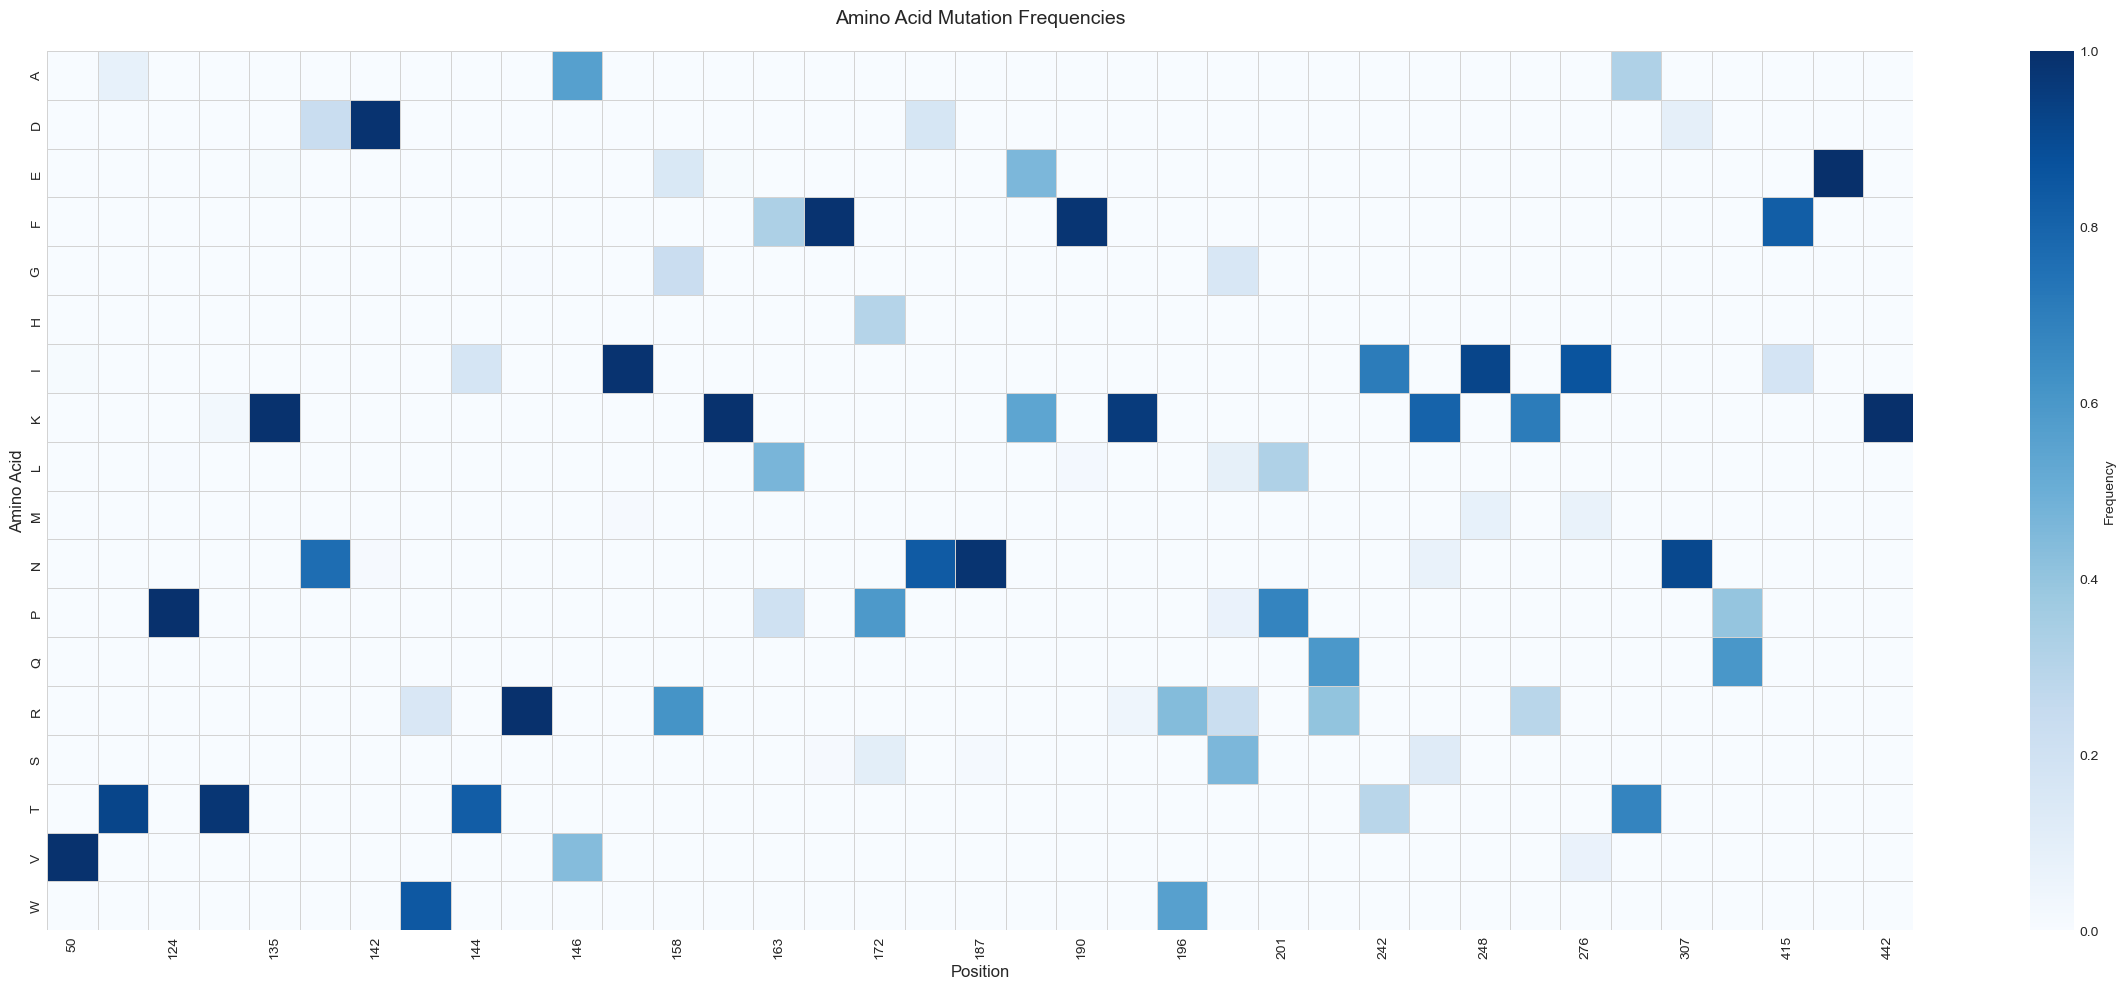

In [12]:
# Save mutation data to CSV
mutation_df.to_csv('mutation_frequencies.csv', index=False)
print("Mutation data saved to mutation_frequencies.csv")

# Save a high-resolution figure
plot_mutation_heatmap(
    mutation_df,
    min_frequency=0.01,
    figsize=(24, 10),
    title="Amino Acid Mutation Frequencies",
    save_path='mutation_heatmap.png'
)

## 8. Advanced: Compare Multiple Datasets

Example of how to compare mutation patterns across different time points or regions.

In [13]:
# Example: Compare two different FASTA files
# fasta_file1 = "../data/timepoint1.fasta"
# fasta_file2 = "../data/timepoint2.fasta"

# mutation_df1 = reader.fasta_to_aa_mutations(fasta_file1)
# mutation_df2 = reader.fasta_to_aa_mutations(fasta_file2)

# # Create side-by-side comparison
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12))

# # Plot first dataset
# plt.sca(ax1)
# plot_mutation_heatmap(mutation_df1, min_frequency=0.01, title="Time Point 1")

# # Plot second dataset
# plt.sca(ax2)
# plot_mutation_heatmap(mutation_df2, min_frequency=0.01, title="Time Point 2")

# plt.tight_layout()
# plt.show()